# Full Process Walkthrough Notebook

本 notebook 是项目全过程展示的主线文件，用一个轻量、可复跑的合成轴承样本串起数据接入、预处理、窗口划分、特征工程、标签构造、模型训练、预测输出和可视化。当前版本已经写到特征工程，后续 review 到哪一段，就继续在本文件后面追加。

## 全流程目录（持续补充）

- [x] 数据实体与样本表
- [x] 预处理可选项
- [x] 滑动窗口切分
- [x] 特征工程：manual_19 与 tsfresh backend
- [ ] RUL 标签与生存分析字段
- [ ] 模型训练与评估
- [ ] 预测输出与可视化

## 1. 准备一个轴承实体

为了让 notebook 不依赖本机的大型真实数据集，这里使用 `SyntheticBearingFactory` 生成一个小型 run-to-failure 样本。真实 XJTU-SY 或 PHM2012 数据进入项目后，也会被整理为同样的 `BearingEntity` 语义。

In [1]:
# 导入数值计算、表格展示和绘图依赖。
from io import BytesIO
from pathlib import Path
import sys

import matplotlib
import numpy as np
import pandas as pd

# 使用非交互式后端，避免运行 notebook 时弹出独立绘图窗口。
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 关闭交互模式；图像会在最后通过 display(Image(...)) 内嵌展示。
plt.ioff()

# 允许从项目根目录或 examples 目录直接运行 notebook，而不依赖外部 PYTHONPATH。
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "USTC").exists() and (PROJECT_ROOT.parent / "src" / "USTC").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# 从项目模块导入数据实体工厂、特征后端、RUL 标签构造器和预处理组件。
from USTC.SSE.BearingPrediction.data import SyntheticBearingFactory
from USTC.SSE.BearingPrediction.feature import create_feature_backend
from USTC.SSE.BearingPrediction.labeling import BearingRulLabeler
from USTC.SSE.BearingPrediction.preprocess import (
    MinMaxNormalize,
    PreprocessingPipeline,
    RobustClip,
    SlidingWindowConfig,
    SlidingWindowSegmenter,
    ZScoreNormalize,
)

# 固定随机种子，让 notebook 每次运行都生成一致的示例信号。
factory = SyntheticBearingFactory(random_state=7)
# 生成一个小型 run-to-failure 轴承实体：8 个时间快照，每个快照 256 个采样点。
entity = factory.create_run_to_failure_entity(
    "Bearing_Demo_01",
    snapshot_count=8,
    signal_length=256,
)

# 打印实体元信息，确认后续流程使用统一的 BearingEntity 接口。
print("entity:", entity.entity_id)
print("dataset:", entity.dataset_name)
print("channels:", entity.channel_names())
print(entity.samples[["sample_index", "timestamp", "rul"]].head().to_string(index=False))

# 基础校验：需要有水平振动通道，且 run-to-failure 样本中的 RUL 应随时间递减。
assert "Horizontal Vibration" in entity.channel_names()
assert entity.samples["rul"].iloc[0] > entity.samples["rul"].iloc[-1]

entity: Bearing_Demo_01
dataset: Synthetic
channels: ['Horizontal Vibration', 'Vertical Vibration']
 sample_index  timestamp  rul
            0          0    7
            1          1    6
            2          2    5
            3          3    4
            4          4    3


## 2. 预处理不是固定开关，而是可配置流水线

项目代码中的 `PreprocessingPipeline` 接收 transform 列表，因此预处理应理解为可组合流程。当前高层 labeler 默认使用鲁棒裁剪和 Z-score 归一化；如果实验需要，也可以替换为 Min-Max 归一化，或在更底层重组 transform 列表。

In [2]:
# 选择一个振动通道作为当前演示对象。
channel_name = "Horizontal Vibration"
# 取出第一个时间快照的原始振动序列，并统一为 float32 数组。
raw_signal = np.asarray(entity.samples.iloc[0][channel_name], dtype=np.float32)

# 组装两条预处理流水线，用来对比不同归一化策略。
zscore_pipeline = PreprocessingPipeline([RobustClip(), ZScoreNormalize()])
minmax_pipeline = PreprocessingPipeline([RobustClip(), MinMaxNormalize()])

# 对同一条原始信号分别应用预处理，便于说明预处理是可替换配置。
zscore_signal = zscore_pipeline.apply(raw_signal)
minmax_signal = minmax_pipeline.apply(raw_signal)

# 汇总均值、标准差和取值范围，直观看到预处理对数据尺度的影响。
summary = pd.DataFrame(
    [
        {
            "variant": "raw",
            "mean": raw_signal.mean(),
            "std": raw_signal.std(),
            "min": raw_signal.min(),
            "max": raw_signal.max(),
        },
        {
            "variant": "robust_clip + zscore",
            "mean": zscore_signal.mean(),
            "std": zscore_signal.std(),
            "min": zscore_signal.min(),
            "max": zscore_signal.max(),
        },
        {
            "variant": "robust_clip + minmax",
            "mean": minmax_signal.mean(),
            "std": minmax_signal.std(),
            "min": minmax_signal.min(),
            "max": minmax_signal.max(),
        },
    ]
)

print(summary.round(4).to_string(index=False))
# 用断言把关键预处理期望写进 notebook：Z-score 均值接近 0，Min-Max 范围在 [0, 1]。
assert abs(float(zscore_signal.mean())) < 1e-5
assert 0.0 <= float(minmax_signal.min()) <= float(minmax_signal.max()) <= 1.0

             variant    mean    std     min    max
                 raw -0.0187 0.5390 -1.1179 0.9889
robust_clip + zscore  0.0000 1.0000 -2.0392 1.8693
robust_clip + minmax  0.5217 0.2559  0.0000 1.0000


## 3. 滑动窗口切分

窗口切分的作用是把一段较长振动信号转成模型可接收的固定长度张量。`window_size` 决定每个输入片段长度，`stride` 决定相邻窗口的步长和重叠程度。对同一个快照切出的多个窗口，通常继承该快照的同一个 RUL 标签。

In [3]:
# 每个窗口包含 64 个采样点；步长为 32，表示相邻窗口有 50% 重叠。
window_size = 64
stride = 32
# SlidingWindowSegmenter 只负责窗口切分，不负责生成 RUL 或生存分析标签。
segmenter = SlidingWindowSegmenter(SlidingWindowConfig(window_size=window_size, stride=stride))
windows = segmenter.segment(zscore_signal)
# 将窗口列表堆叠成二维数组，形状为：窗口数 x 窗口长度。
window_array = np.stack(windows)

# 记录每个窗口在原始快照中的起止位置，并继承该快照的同一个 RUL。
window_frame = pd.DataFrame(
    {
        "window_index": np.arange(len(windows)),
        "start": np.arange(len(windows)) * stride,
        "end": np.arange(len(windows)) * stride + window_size,
        "inherited_rul": float(entity.samples.iloc[0]["rul"]),
    }
)

print("window array shape:", window_array.shape)
print(window_frame.to_string(index=False))

# 校验窗口数量公式：1 + floor((signal_length - window_size) / stride)。
expected_window_count = 1 + (raw_signal.size - window_size) // stride
assert window_array.shape == (expected_window_count, window_size)
# 同一快照切出的窗口只改变输入片段，不改变该快照对应的 RUL 标签。
assert window_frame["inherited_rul"].nunique() == 1

window array shape: (7, 64)
 window_index  start  end  inherited_rul
            0      0   64            7.0
            1     32   96            7.0
            2     64  128            7.0
            3     96  160            7.0
            4    128  192            7.0
            5    160  224            7.0
            6    192  256            7.0


## 4. 与高层 RUL labeler 对齐

`BearingRulLabeler` 把预处理、窗口切分和 RUL 目标组织成训练数据集。这里的默认策略是鲁棒裁剪、Z-score 归一化和滑动窗口切分；归一化方式、窗口大小、步长和输入表示都可以通过参数调整。

In [4]:
# 高层 RUL labeler 会复用上述思路：预处理、窗口切分、再绑定 RUL 目标值。
labeler = BearingRulLabeler(
    window_size=window_size,
    stride=stride,
    input_representation="raw_signal",
    normalization="zscore",
)
# 将 BearingEntity 转换成可供模型训练使用的输入张量、目标数组和元数据表。
rul_dataset = labeler.label(entity, channel_name)

print("inputs shape:", rul_dataset.inputs.shape)
print("targets shape:", rul_dataset.targets.shape)
print("target name:", rul_dataset.target_name)
print(rul_dataset.metadata_frame.head(8).to_string(index=False))

# 校验 labeler 输出语义：目标名是 RUL，输入窗口长度与配置一致，输入和标签一一对应。
assert rul_dataset.target_name == "rul"
assert rul_dataset.inputs.shape[1] == window_size
assert rul_dataset.targets.shape[0] == rul_dataset.inputs.shape[0]
assert rul_dataset.metadata_frame["window_index"].max() == expected_window_count - 1

inputs shape: (56, 64)
targets shape: (56,)
target name: rul
      entity_id dataset_name  sample_index  window_index         channel_name
Bearing_Demo_01    Synthetic             0             0 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             1 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             2 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             3 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             4 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             5 Horizontal Vibration
Bearing_Demo_01    Synthetic             0             6 Horizontal Vibration
Bearing_Demo_01    Synthetic             1             0 Horizontal Vibration


## 5. 调用 tsfresh feature backend

特征分析是公共表征层，本身不区分 RUL 预测或生存分析。这里先用系统默认 `manual_19` backend 生成 19 维自定义时频域特征，再调用 `tsfresh_minimal` backend 自动生成特征，最后展示 `manual_19_plus_tsfresh_minimal` 融合特征。`tsfresh` 属于 optional advanced 依赖；如果当前环境没有安装，本 cell 会打印跳过说明。

In [5]:
# feature backend 接收滑动窗口列表，输出与窗口一一对应的 feature frame。
manual_backend = create_feature_backend("manual_19", sample_rate=entity.sample_rate)
manual_feature_frame = manual_backend.extract(windows)

print("manual_19 shape:", manual_feature_frame.shape)
print(
    manual_feature_frame[["rms", "peak", "spectrum_energy", "kurtosis"]]
    .round(4)
    .head()
    .to_string(index=False)
)

try:
    # tsfresh_minimal 使用 tsfresh 的 MinimalFCParameters，适合 notebook 中快速展示。
    tsfresh_backend = create_feature_backend("tsfresh_minimal", sample_rate=entity.sample_rate)
    tsfresh_feature_frame = tsfresh_backend.extract(windows)

    # 融合 backend 会保留 19 个手工特征，并给 tsfresh 列加上 tsfresh__ 前缀。
    combined_backend = create_feature_backend("manual_19_plus_tsfresh_minimal", sample_rate=entity.sample_rate)
    combined_feature_frame = combined_backend.extract(windows)

    print("\ntsfresh_minimal shape:", tsfresh_feature_frame.shape)
    print("tsfresh columns:", tsfresh_feature_frame.columns.tolist())
    print(tsfresh_feature_frame.round(4).head().to_string(index=False))

    print("\nmanual_19 + tsfresh_minimal shape:", combined_feature_frame.shape)
    print("combined first columns:", combined_feature_frame.columns[:8].tolist())
    print("combined tsfresh columns:", [column for column in combined_feature_frame.columns if column.startswith("tsfresh__")][:8])

    assert tsfresh_feature_frame.shape[0] == expected_window_count
    assert combined_feature_frame.shape[0] == expected_window_count
    assert combined_feature_frame.shape[1] == manual_feature_frame.shape[1] + tsfresh_feature_frame.shape[1]
except RuntimeError as exc:
    tsfresh_feature_frame = pd.DataFrame()
    combined_feature_frame = manual_feature_frame.copy()
    print("tsfresh backend unavailable:", exc)
    print("Install advanced dependencies with: uv sync --extra advanced")

# 无论 tsfresh 是否可用，manual_19 都应稳定产出 19 个项目自定义特征。
assert manual_feature_frame.shape == (expected_window_count, 19)

manual_19 shape: (7, 19)
   rms   peak  spectrum_energy  kurtosis
1.0443 2.0067        2244.2178    2.0710
0.9928 1.8588        2027.1874    1.9324
0.9428 1.7459        1829.9696    1.7801
1.0052 1.7523        2069.8230    1.6725
0.9544 1.7523        1876.5049    1.8373

tsfresh_minimal shape: (7, 10)
tsfresh columns: ['value__sum_values', 'value__median', 'value__mean', 'value__length', 'value__standard_deviation', 'value__variance', 'value__root_mean_square', 'value__maximum', 'value__absolute_maximum', 'value__minimum']
 value__sum_values  value__median  value__mean  value__length  value__standard_deviation  value__variance  value__root_mean_square  value__maximum  value__absolute_maximum  value__minimum
            4.3898         0.3910       0.0686           64.0                     1.0421           1.0860                   1.0443          1.6444                   2.0067         -2.0067
           -4.1191        -0.1444      -0.0644           64.0                     0.9907       

## 6. 快速可视化

图中上半部分对比原始信号和 Z-score 后的信号；下半部分展示前三个窗口。窗口之间有重叠，这是由 `stride < window_size` 决定的。

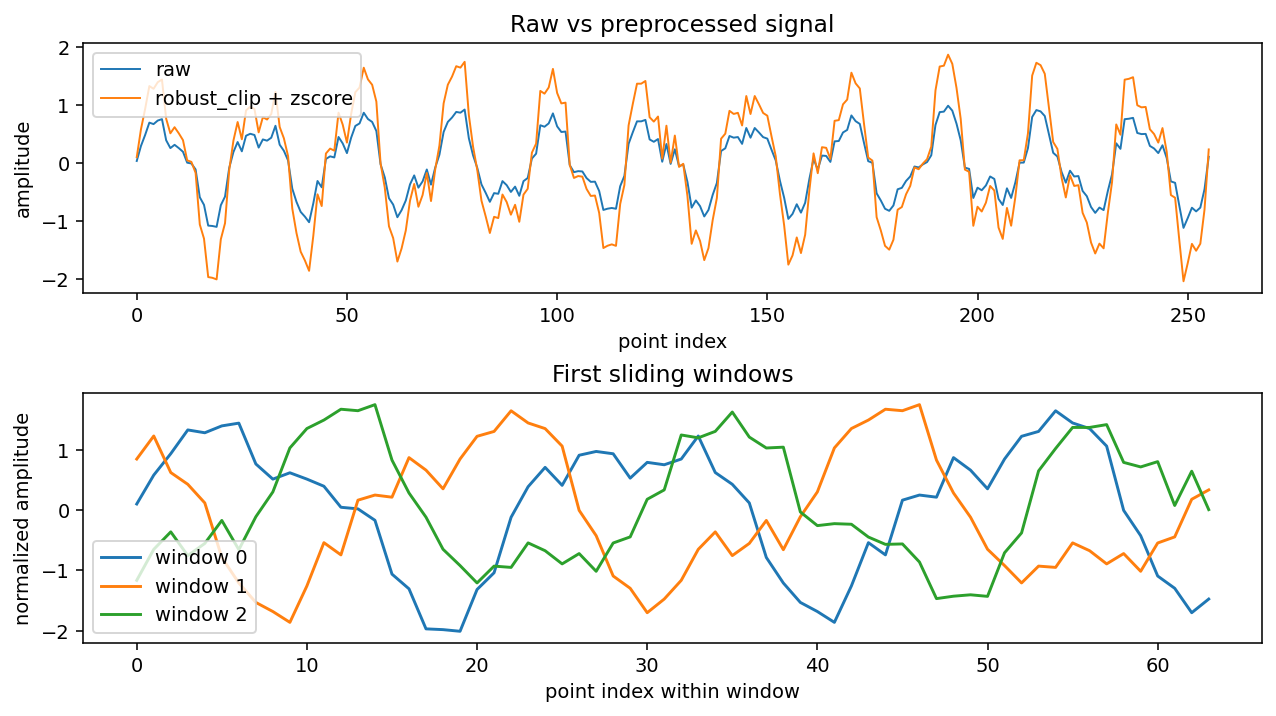

preprocessing and window segmentation demo completed


In [7]:
# 创建上下两幅图：上图看原始/预处理信号，下图看窗口切分后的片段。
fig, axes = plt.subplots(2, 1, figsize=(9, 5), constrained_layout=True)

# 对比原始信号和鲁棒裁剪 + Z-score 后的信号。
axes[0].plot(raw_signal, label="raw", linewidth=1.0)
axes[0].plot(zscore_signal, label="robust_clip + zscore", linewidth=1.0)
axes[0].set_title("Raw vs preprocessed signal")
axes[0].set_xlabel("point index")
axes[0].set_ylabel("amplitude")
axes[0].legend()

# 展示前三个窗口，说明 stride 小于 window_size 时窗口之间存在重叠。
for window_index in range(min(3, len(windows))):
    axes[1].plot(window_array[window_index], label=f"window {window_index}")
axes[1].set_title("First sliding windows")
axes[1].set_xlabel("point index within window")
axes[1].set_ylabel("normalized amplitude")
axes[1].legend()

# 将图像写入内存 PNG，再以内嵌图片形式展示，避免 plt.show() 弹出系统窗口。
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=140, bbox_inches="tight")
image_buffer.seek(0)
display(Image(data=image_buffer.getvalue()))

# 关闭 figure，避免批量测试时累积图形对象。
plt.close(fig)
print("preprocessing and window segmentation demo completed")

## 当前小结

到这里，主线 notebook 已经覆盖数据实体、预处理可选项、滑动窗口切分、RUL 训练样本构造，以及 `manual_19` / `tsfresh` 特征 backend 调用。后续不再新开局部 notebook，而是在本文件继续追加 RUL 标签语义、生存分析字段、模型训练、预测输出和可视化章节。